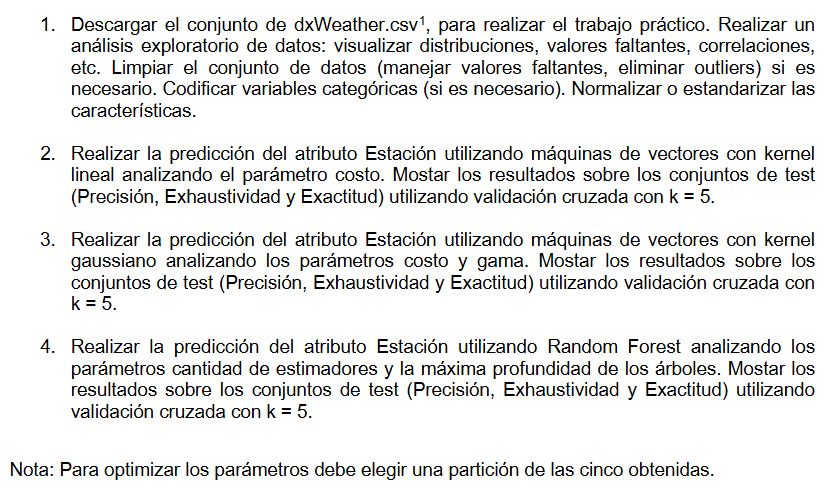

In [91]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, validation_curve
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, LabelEncoder

# Clasificador SVM
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             ConfusionMatrixDisplay ,classification_report)
import warnings
warnings.filterwarnings('ignore')

In [92]:
df = pd.read_csv('dxWeather.csv')

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10090 entries, 0 to 10089
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Temperatura         10090 non-null  int64  
 1   Humedad             10090 non-null  int64  
 2   VientoVelocidad     10090 non-null  float64
 3   Precipitation       10090 non-null  int64  
 4   PresionAtmosferica  10090 non-null  float64
 5   Localizacion        10090 non-null  object 
 6   TipoClima           10090 non-null  object 
 7   Estacion            10090 non-null  object 
dtypes: float64(2), int64(3), object(3)
memory usage: 630.8+ KB


In [65]:
df.head()

,Temperatura,Humedad,VientoVelocidad,Precipitation,PresionAtmosferica,Localizacion,TipoClima,Estacion
0,39,96,8.5,71,1011.43,Llanura,Nublado,Primavera
1,30,64,7.0,16,1018.72,Montania,Soleado,Primavera
2,38,83,1.5,82,1026.25,Costa,Soleado,Primavera
3,32,55,3.5,26,1010.03,Llanura,Nublado,Verano
4,3,85,6.0,96,984.46,Llanura,Nevado,Invierno


In [66]:
X = df.drop('Estacion', axis=1)
y = df['Estacion']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Tratamiento de nulos

In [67]:
X_train.isna().sum()

Temperatura           0
Humedad               0
VientoVelocidad       0
Precipitation         0
PresionAtmosferica    0
Localizacion          0
TipoClima             0
dtype: int64

No se visualizan valores faltantes

In [68]:
y_train.isna().sum()

np.int64(0)

No se observar valores faltantes

## Analisis valores imposibles

In [69]:
X_train.shape, y_train.shape

((8072, 7), (8072,))

In [70]:
print(f"Filas con Humedad > 100:  {(X_train['Humedad'] > 100).sum()}")
print(f"Filas con Temperatura < -30:  {(X_train['Temperatura'] < -30).sum()}")
print(f"Filas con Temperatura > 50:  {(X_train['Temperatura'] > 50).sum()}")
print(f"Filas con VientoVelocidad < 0:  {(X_train['VientoVelocidad'] < 0).sum()}")
print(f"Filas con Precipitation < 0:  {(X_train['Precipitation'] < 0).sum()}")

Filas con Humedad > 100:  233
Filas con Temperatura < -30:  0
Filas con Temperatura > 50:  242
Filas con VientoVelocidad < 0:  0
Filas con Precipitation < 0:  0


In [71]:
# Eliminamos los valores imposibles
X_train = X_train[(X_train['Humedad'] <= 100) &
                  (X_train['Temperatura'] >= -30) & (X_train['Temperatura'] <= 50) &
                  (X_train['VientoVelocidad'] >= 0) &
                  (X_train['Precipitation'] >= 0)]
y_train = y_train[X_train.index]

In [72]:
X_train.shape, y_train.shape

((7651, 7), (7651,))

# Distribuciones

In [82]:
X_train.describe()

,Temperatura,Humedad,VientoVelocidad,Precipitation,PresionAtmosferica
count,7651.000000,7651.000000,7651.000000,7651.000000,7651.000000
mean,20.429486,65.622141,9.232649,48.583845,1007.318198
std,14.463290,19.522237,6.362162,31.763408,40.002810
min,-22.000000,20.000000,0.000000,0.000000,800.230000
25%,12.000000,54.000000,4.500000,17.000000,997.865000
50%,23.000000,67.000000,8.500000,49.000000,1010.070000
75%,31.000000,79.000000,13.000000,78.000000,1017.705000
max,50.000000,100.000000,47.500000,109.000000,1199.210000


In [73]:
# convertir object a category
for col in X_train.select_dtypes(include=['object']).columns:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')
    y_train = y_train.astype('category')
    y_test = y_test.astype('category')

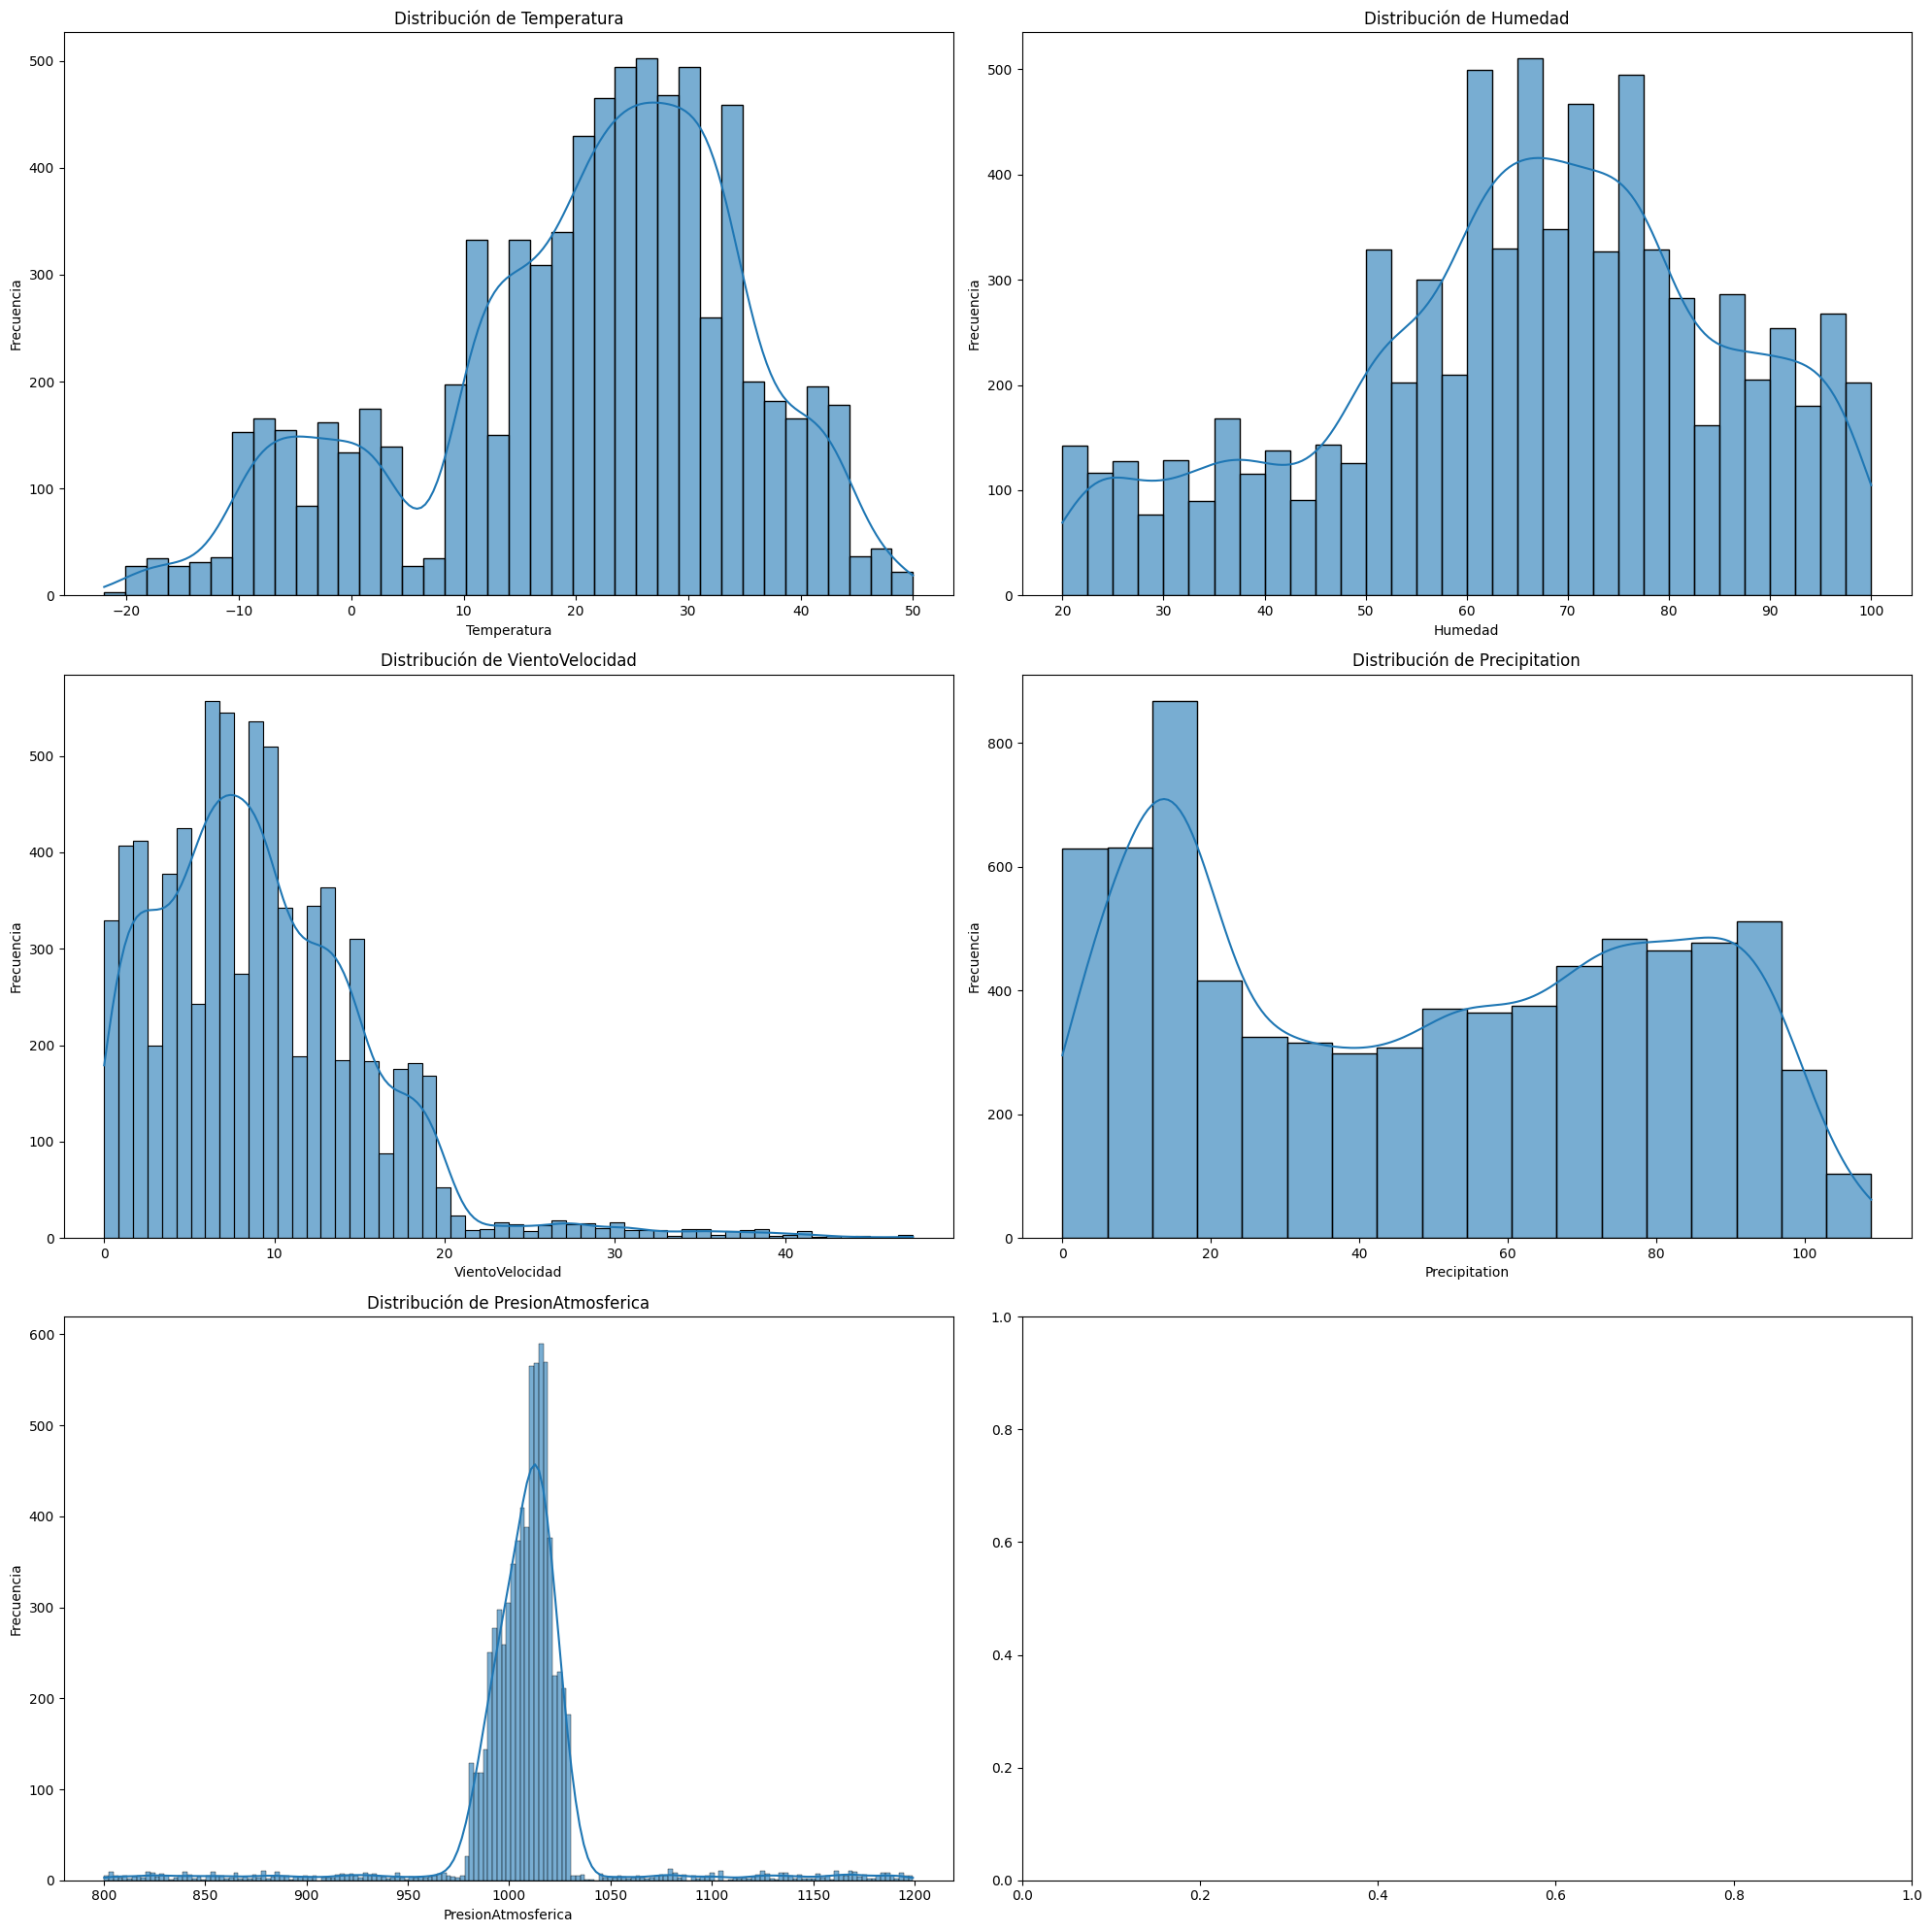

In [74]:
col_numericas = X_train.select_dtypes(include=['float64','int64']).columns

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(20, 20))
axes = axes.flatten()
for i, col in enumerate(col_numericas):
    sns.histplot(data=X_train, x=col, kde=True, ax=axes[i], alpha=0.6)
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()

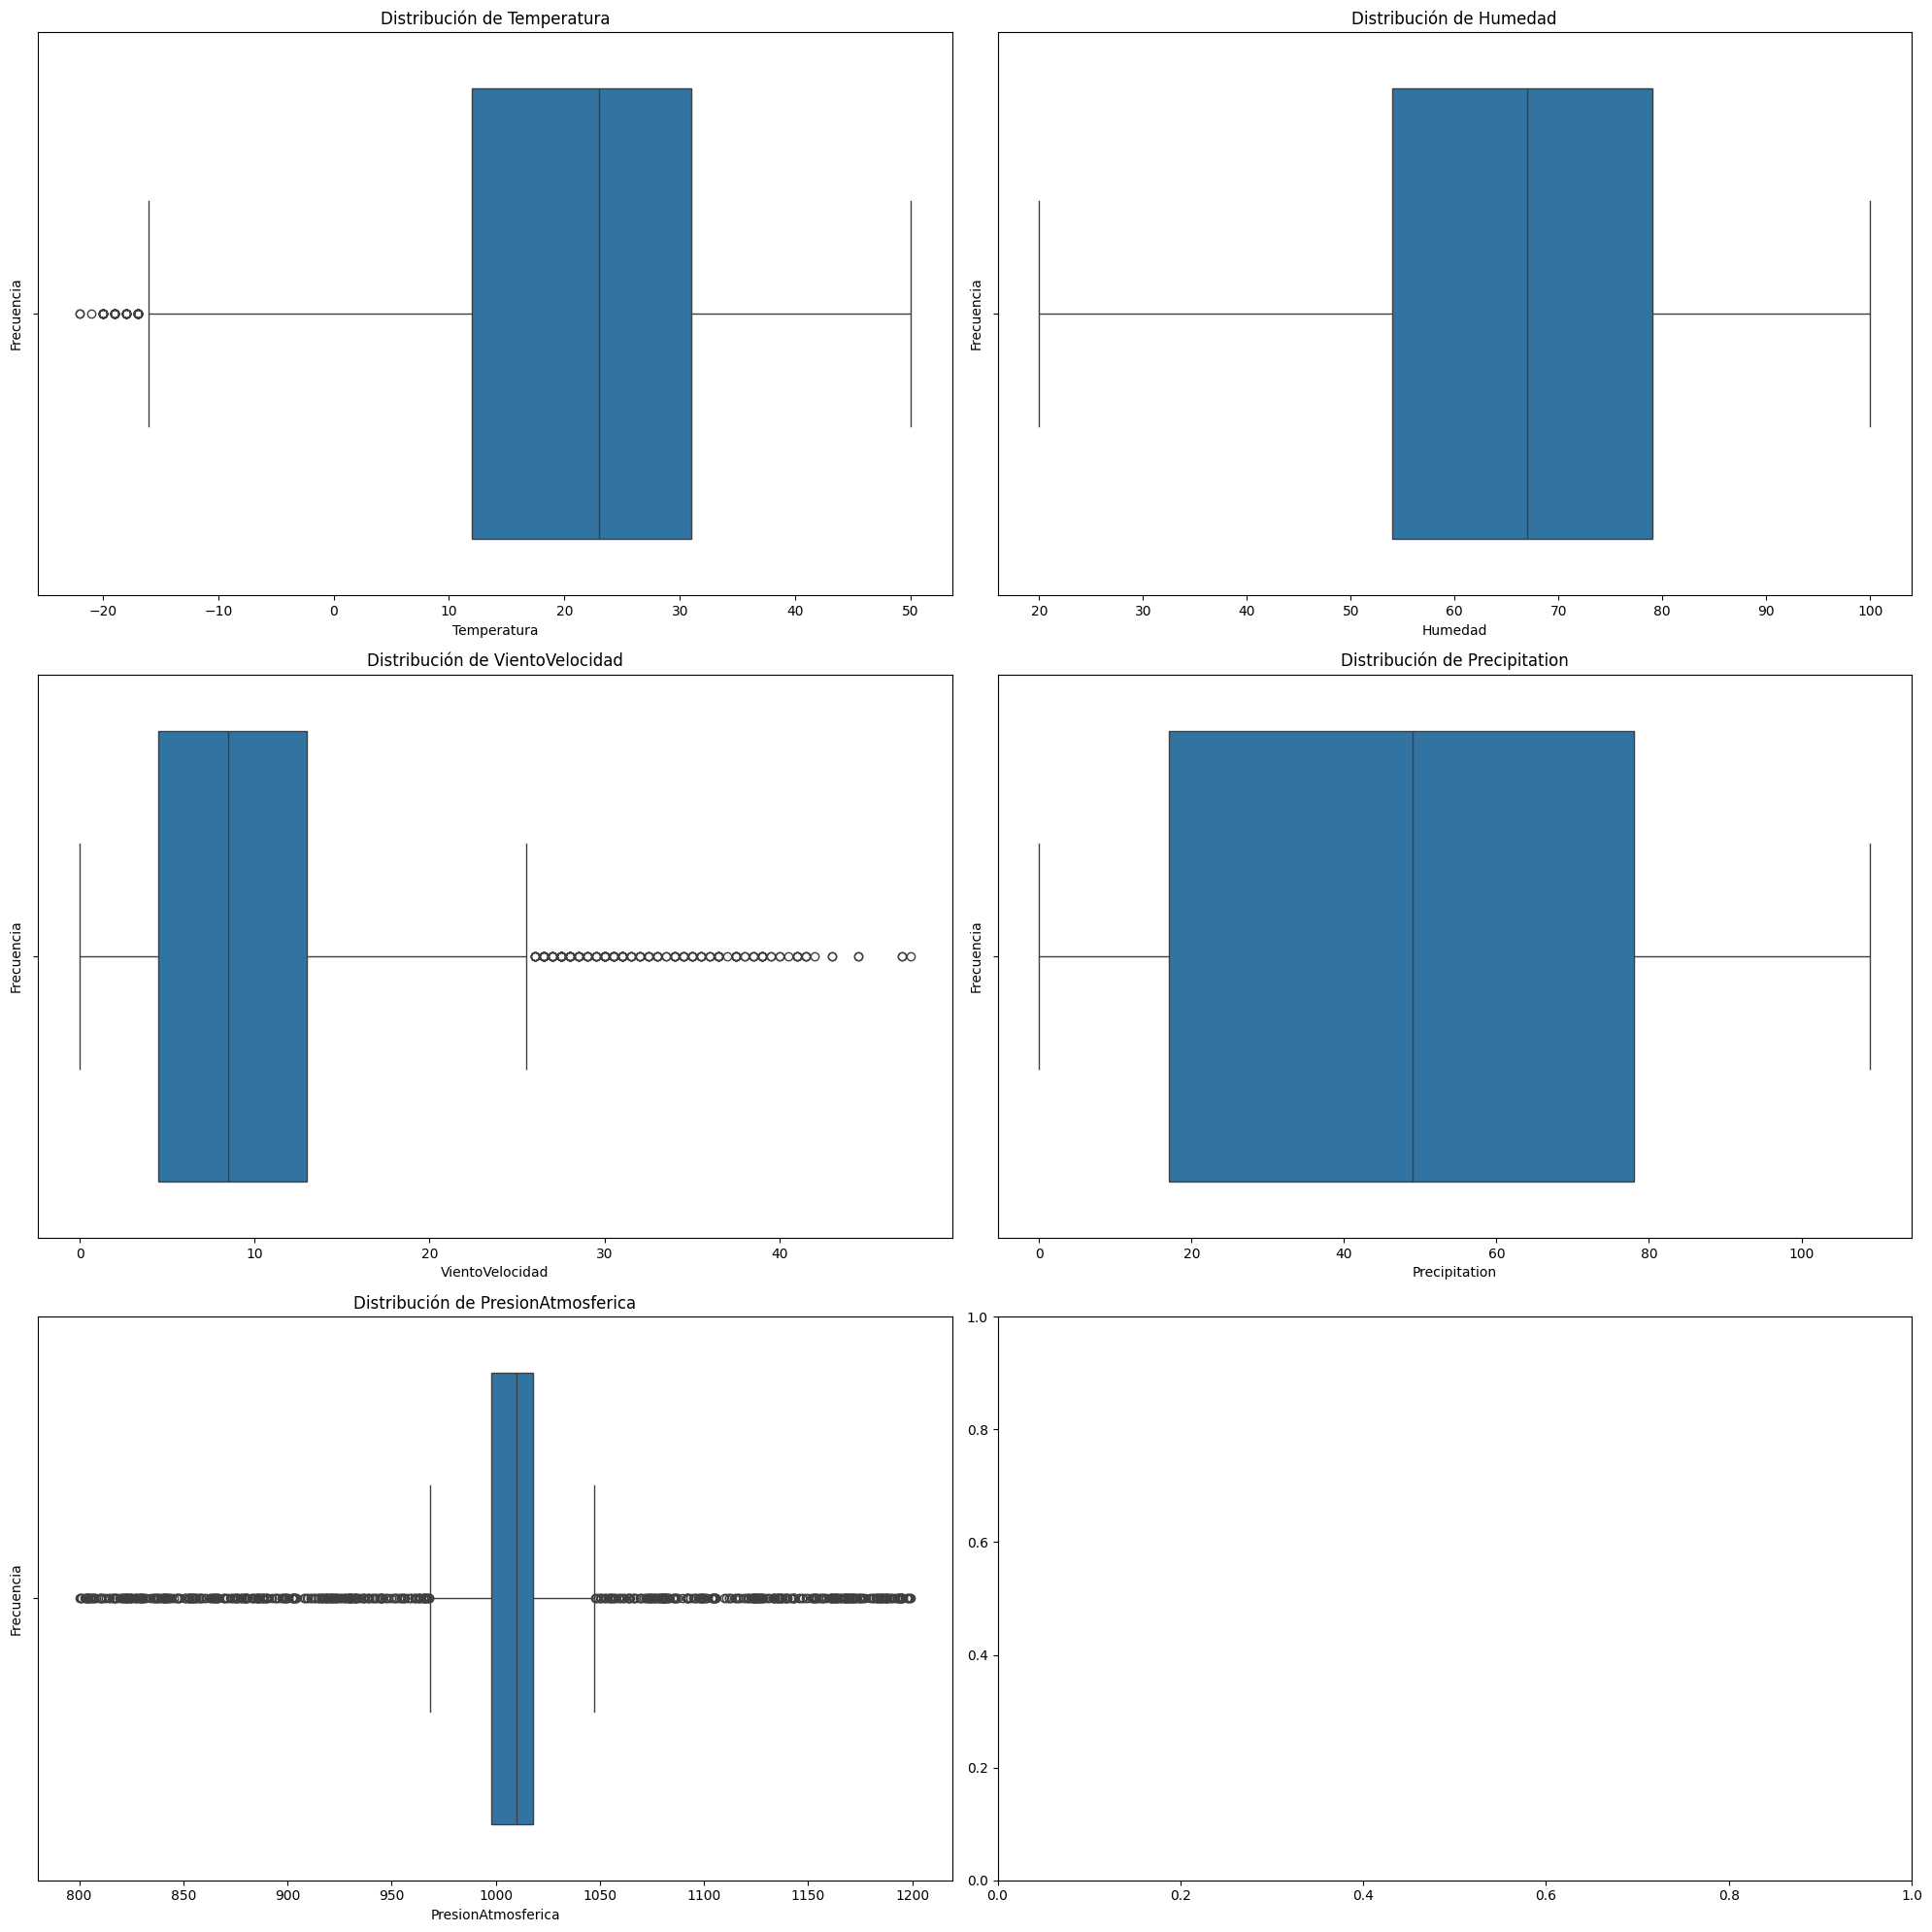

In [75]:
col_numericas = X_train.select_dtypes(include=['float64','int64']).columns

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(20, 20))
axes = axes.flatten()
for i, col in enumerate(col_numericas):
    sns.boxplot(data=X_train, x=col, ax=axes[i])
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()

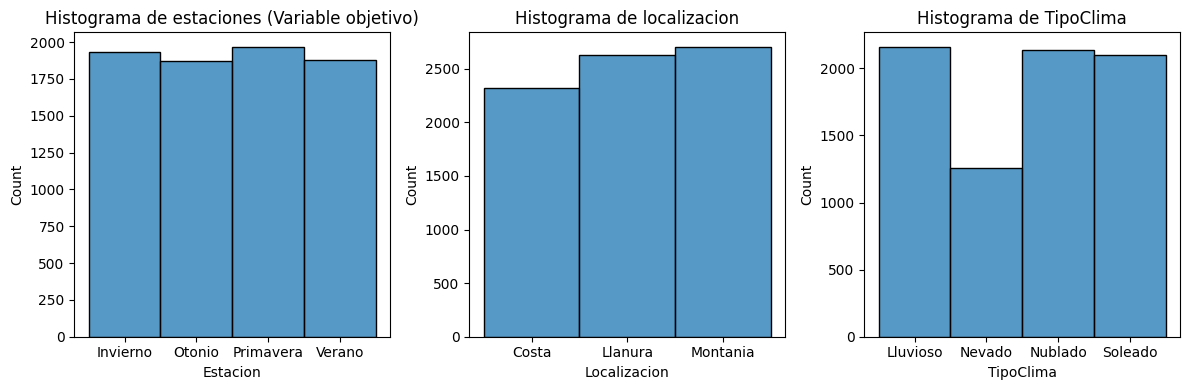

In [81]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Histograma de tarifas
sns.histplot(y_train, ax=axes[0])
axes[0].set_title("Histograma de estaciones (Variable objetivo)")

# Boxplot de tarifas
sns.histplot(X_train["Localizacion"], ax=axes[1])
axes[1].set_title("Histograma de localizacion")

sns.histplot(X_train["TipoClima"], ax=axes[2])
axes[2].set_title("Histograma de TipoClima")

plt.tight_layout()
plt.show()

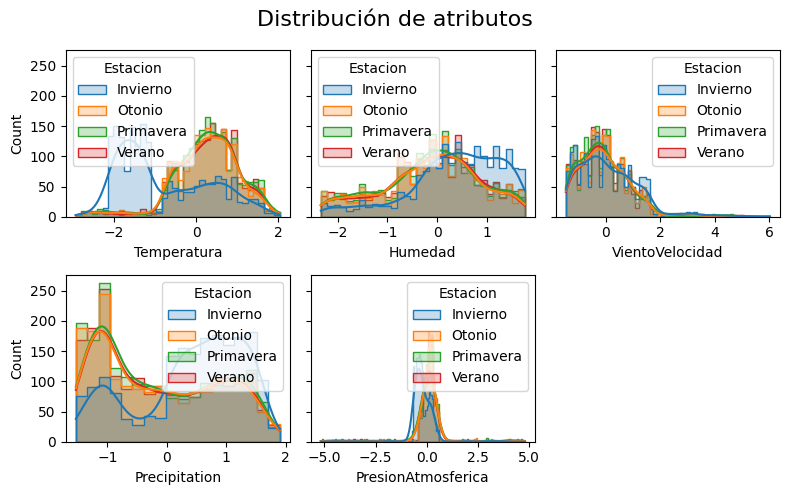

In [93]:
r = 2
c = 3
fig, axes = plt.subplots(nrows=r, ncols=c, sharey=True,
                         figsize=(8, 5))
for i, col in enumerate(col_numericas, 1):
    sns.histplot(data=pd.concat([X_train[col_numericas], y_train], axis=1), x=col,
                 hue='Estacion', kde=True, element='step',
                 ax=axes.flatten()[i-1])

for i in range(len(col_numericas)+1, (r*c)+1):
    axes.flatten()[i-1].axis('off')

plt.suptitle('Distribución de atributos', fontsize=16)
plt.tight_layout()
plt.show()

## Matriz de correlacion

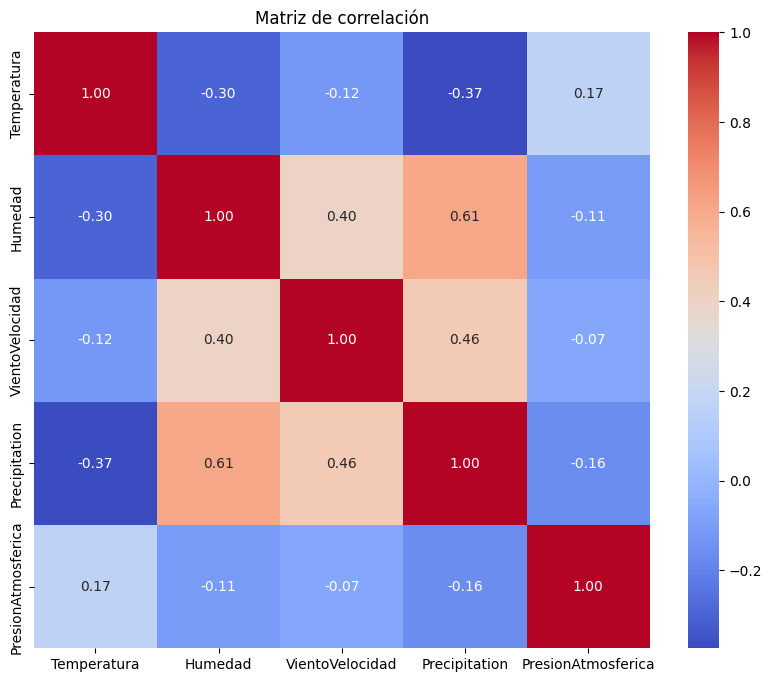

In [80]:
# Matriz de correlacion
col_numericas = X_train.select_dtypes(include=['float64','int64']).columns
plt.figure(figsize=(10, 8))
correlation_matrix = X_train[col_numericas].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("Matriz de correlación")
plt.show()

# Codificacion

In [85]:
le = LabelEncoder()
col_a_escalar = ['Localizacion', 'TipoClima']
for col in col_a_escalar:
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])

In [86]:
X_train.head()

,Temperatura,Humedad,VientoVelocidad,Precipitation,PresionAtmosferica,Localizacion,TipoClima
2036,29,93,6.5,78,1000.35,2,0
1197,10,69,10.5,10,1007.75,0,2
9813,13,47,3.5,49,1190.68,1,0
7535,-4,81,1.5,53,991.79,1,1
7387,30,67,9.5,32,1003.71,1,2


In [ ]:
# aplicamos standard scaler a las columnas numericas
scaler = StandardScaler()
X_train[col_numericas] = scaler.fit_transform(X_train[col_numericas])
X_test[col_numericas] = scaler.transform(X_test[col_numericas])

In [88]:
X_train.head()

,Temperatura,Humedad,VientoVelocidad,Precipitation,PresionAtmosferica,Localizacion,TipoClima
2036,0.592609,1.402485,-0.429544,0.926162,-0.174204,2,0
1197,-0.721148,0.173038,0.199214,-1.214806,0.010795,0,2
9813,-0.513712,-0.953956,-0.901113,0.013103,4.584023,1,0
7535,-1.689179,0.787761,-1.215492,0.139042,-0.388203,1,1
7387,0.661754,0.070584,0.042025,-0.522139,-0.090205,1,2


# SVC

## Lineal

In [95]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, cross_validate
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score

In [126]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100]
}

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision_macro',
    'recall': 'recall_macro'
}

SVC_model = SVC(kernel='linear', random_state=42)

grid_search = GridSearchCV(
    SVC_model,
    param_grid, 
    cv=5,
    scoring=scoring,
    refit='accuracy',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print("Mejores hiperparámetros:", grid_search.best_params_)
print("Mejor accuracy:", grid_search.best_score_)

# Mostrar los resultados promedio
cv_results_lineal_df = pd.DataFrame(grid_search.cv_results_)

cols_to_show = [
    'param_C',
    'mean_test_accuracy', 
    'mean_test_precision', 
    'mean_test_recall'
]
print(cv_results_lineal_df[cols_to_show].sort_values(by='mean_test_accuracy', ascending=False))

print(f"\nMejores hiperparámetros encontrados: {grid_search.best_params_}")
print(f"Mejor Accuracy (CV): {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Mejores hiperparámetros: {'C': 0.1}
Mejor accuracy: 0.3796896385377578
   param_C  mean_test_accuracy  mean_test_precision  mean_test_recall
1     0.10            0.379690             0.344406          0.372127
3    10.00            0.379036             0.338352          0.371530
2     1.00            0.378905             0.334986          0.371399
4   100.00            0.378775             0.338961          0.371270
0     0.01            0.378644             0.265222          0.370875

Mejores hiperparámetros encontrados: {'C': 0.1}
Mejor Accuracy (CV): 0.3797


In [127]:
# test

print("\nMetricas en test")
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

accuracy_test = accuracy_score(y_test, y_pred)
precision_test = precision_score(y_test, y_pred, average='macro')
recall_test = recall_score(y_test, y_pred, average='macro')

print(f"Exactitud (Accuracy) en Test: {accuracy_test:.4f}")
print(f"Precisión (Precision) en Test (macro): {precision_test:.4f}")
print(f"Exhaustividad (Recall) en Test (macro): {recall_test:.4f}")

print("\nReporte de Clasificación:")

print(classification_report(y_test, y_pred, target_names=le.classes_))


Metricas en test
Exactitud (Accuracy) en Test: 0.3687
Precisión (Precision) en Test (macro): 0.3433
Exhaustividad (Recall) en Test (macro): 0.3615

Reporte de Clasificación:
              precision    recall  f1-score   support

    Lluvioso       0.63      0.57      0.60       498
      Nevado       0.27      0.01      0.01       506
     Nublado       0.30      0.86      0.44       526
     Soleado       0.18      0.01      0.02       488

    accuracy                           0.37      2018
   macro avg       0.34      0.36      0.27      2018
weighted avg       0.34      0.37      0.27      2018



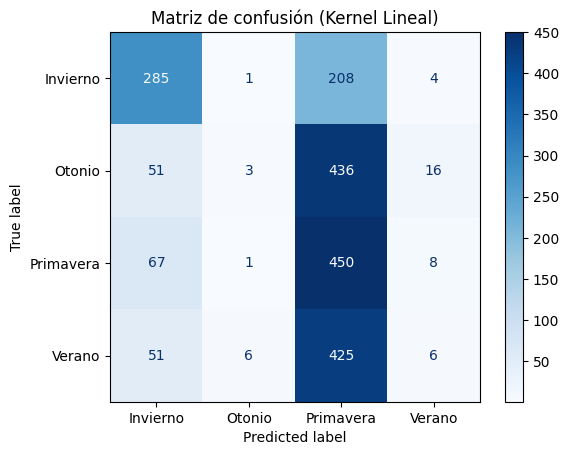

In [129]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=best_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de confusión (Kernel Lineal)")
plt.show()

## RBF Gaussiana

In [122]:
SVC_rbf_model = SVC(kernel='rbf', random_state=42)

param_grid_rbf = {
    'C': [0.1, 1, 10, 100],       
    'gamma': ['scale', 'auto', 0.1, 1]  
}

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision_macro',
    'recall': 'recall_macro'
}

grid_search_rbf = GridSearchCV(
    SVC_rbf_model,
    param_grid_rbf,
    cv=5,
    scoring=scoring,
    refit='accuracy',
    verbose=1,
    n_jobs=-1
)

grid_search_rbf.fit(X_train, y_train)

# Mostrar los resultados promedio
cv_results_rbf_df = pd.DataFrame(grid_search_rbf.cv_results_)

cols_to_show = [
    'param_C', 
    'param_gamma',
    'mean_test_accuracy', 
    'mean_test_precision', 
    'mean_test_recall'
]
print(cv_results_rbf_df[cols_to_show].sort_values(by='mean_test_accuracy', ascending=False))

print(f"\nMejores hiperparámetros encontrados: {grid_search_rbf.best_params_}")
print(f"Mejor Accuracy (CV): {grid_search_rbf.best_score_:.4f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
    param_C param_gamma  mean_test_accuracy  mean_test_precision  \
0       0.1       scale            0.389361             0.427256   
1       0.1        auto            0.389360             0.522383   
2       0.1         0.1            0.389230             0.372607   
3       0.1           1            0.388838             0.446809   
7       1.0           1            0.385571             0.455967   
9      10.0        auto            0.384657             0.443318   
10     10.0         0.1            0.383351             0.444338   
5       1.0        auto            0.383220             0.454066   
4       1.0       scale            0.382567             0.450527   
8      10.0       scale            0.382566             0.443717   
11     10.0           1            0.382434             0.408849   
6       1.0         0.1            0.381913             0.449264   
14    100.0         0.1            0.381912            

In [123]:
# test

print("\nMetricas en test")
best_rbf_model = grid_search_rbf.best_estimator_
y_pred_rbf = best_rbf_model.predict(X_test)

accuracy_test = accuracy_score(y_test, y_pred_rbf)
precision_test = precision_score(y_test, y_pred_rbf, average='macro')
recall_test = recall_score(y_test, y_pred_rbf, average='macro')

print(f"Exactitud (Accuracy) en Test: {accuracy_test:.4f}")
print(f"Precisión (Precision) en Test (macro): {precision_test:.4f}")
print(f"Exhaustividad (Recall) en Test (macro): {recall_test:.4f}")

print("\nReporte de Clasificación:")

print(classification_report(y_test, y_pred_rbf, target_names=le.classes_))


Metricas en test
Exactitud (Accuracy) en Test: 0.3855
Precisión (Precision) en Test (macro): 0.5041
Exhaustividad (Recall) en Test (macro): 0.3775

Reporte de Clasificación:
              precision    recall  f1-score   support

    Lluvioso       0.96      0.53      0.68       498
      Nevado       0.50      0.00      0.00       506
     Nublado       0.30      0.94      0.45       526
     Soleado       0.26      0.04      0.07       488

    accuracy                           0.39      2018
   macro avg       0.50      0.38      0.30      2018
weighted avg       0.50      0.39      0.30      2018



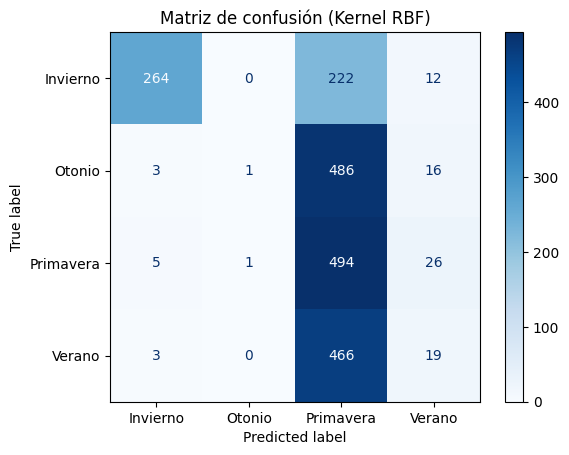

In [124]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_rbf, labels=best_rbf_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=best_rbf_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de confusión (Kernel RBF)")
plt.show()